In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [1]:
import zipfile

zip_path = "/content/cat and dog.zip"
extract_path = "/content/cat_dog"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Giải nén xong!")

BadZipFile: File is not a zip file

In [2]:
import os

print(os.path.getsize("/content/cat and dog.zip"))

165675008


In [3]:
!xxd -l 16 "/content/cat and dog.zip"

00000000: 504b 0304 2d00 0000 0800 4a0d 3e4f 6a00  PK..-.....J.>Oj.


In [4]:
!unzip -t "/content/cat and dog.zip"

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
    testing: training_set/training_set/cats/cat.3705.jpg   OK
    testing: training_set/training_set/cats/cat.3706.jpg   OK
    testing: training_set/training_set/cats/cat.3707.jpg   OK
    testing: training_set/training_set/cats/cat.3708.jpg   OK
    testing: training_set/training_set/cats/cat.3709.jpg   OK
    testing: training_set/training_set/cats/cat.371.jpg   OK
    testing: training_set/training_set/cats/cat.3710.jpg   OK
    testing: training_set/training_set/cats/cat.3711.jpg   OK
    testing: training_set/training_set/cats/cat.3712.jpg   OK
    testing: training_set/training_set/cats/cat.3713.jpg   OK
    testing: training_set/training_set/cats/cat.3714.jpg   OK
    testing: training_set/training_set/cats/cat.3715.jpg   OK
    testing: training_set/training_set/cats/cat.3716.jpg   OK
    testing: training_set/training_set/cats/cat.3717.jpg   OK
    testing: training_set/training_set/cats/cat.3718.jpg   OK
    testing: t

In [5]:
!unzip "/content/cat and dog.zip" -d "/content/cat_dog"

Kết quả truyền trực tuyến bị cắt bớt đến 5000 dòng cuối.
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3704.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3705.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3706.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3707.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3708.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3709.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.371.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3710.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3711.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3712.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3713.jpg  
  inflating: /content/cat_dog/training_set/training_set/cats/cat.3714.jpg  
  inflating: /content/cat_dog/tr

In [6]:
import os

print(os.listdir("/content/cat_dog"))

['test_set', 'training_set']


In [7]:
import tensorflow as tf

train_path = "/content/cat_dog/training_set/training_set"
test_path = "/content/cat_dog/test_set/test_set"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

print(train_ds.class_names)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
['cats', 'dogs']


In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 184s 686ms/step - accuracy: 0.5379 - loss: 2.3739 - val_accuracy: 0.5615 - val_loss: 0.6769
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 180s 638ms/step - accuracy: 0.5606 - loss: 0.6795 - val_accuracy: 0.5610 - val_loss: 0.6768
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 620ms/step - accuracy: 0.5560 - loss: 0.6889 - val_accuracy: 0.5447 - val_loss: 0.6860
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 209s 650ms/step - accuracy: 0.5694 - loss: 0.6691 - val_accuracy: 0.5517 - val_loss: 0.6846
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 624ms/step - accuracy: 0.5919 - loss: 0.6543 - val_accuracy: 0.5610 - val_loss: 0.6941
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 156s 621ms/step - accuracy: 0.6092 - loss: 0.6372 - val_accuracy: 0.5660 - val_loss: 0.7055
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 164s 655ms/step - accuracy: 0.6407 - loss: 0.6131 - val_accuracy: 0.5729 - val_loss: 0.7069
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 161s 641ms/step - accuracy: 0.6697 -

In [12]:
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.6041 - loss: 0.7677
Test Accuracy: 0.6040533781051636


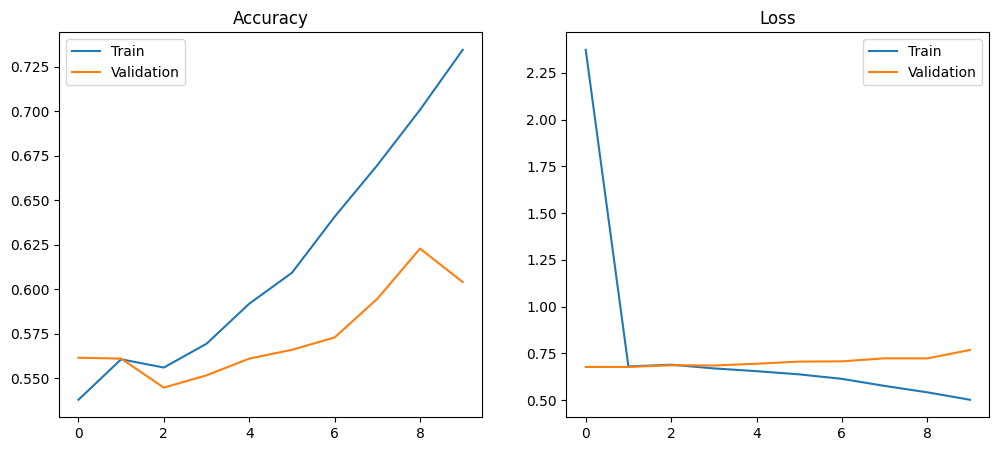

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

In [16]:
model.save("cat_dog_model.keras")